In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,pvi,census_region,dem_scandal_score,rep_scandal_score,Year,Geography,dem_stand,rep_stand,inc_dummy,polarization
0,0,2014,Alabama,AL,False,AL-01,48278.0,103758.0,152234,Burton LeFlore,...,-14.460266,East South Central,0.0,0.0,2014.0,AL-01,Burton LeFlore,Bradley Byrne,-1,0.875383
1,1,2014,Alabama,AL,False,AL-02,54692.0,113103.0,167952,Erick Wright,...,-16.091761,East South Central,0.0,0.0,2014.0,AL-02,Erick Wright,Martha Roby,-1,0.875383
2,2,2014,Alabama,AL,False,AL-03,52816.0,103558.0,156620,Jesse Smith,...,-15.311107,East South Central,0.0,0.0,2014.0,AL-03,Jesse Smith,Mike Rogers,-1,0.875383
3,3,2014,Alabama,AL,False,AL-06,42291.0,135945.0,178449,Mark Lester,...,-27.395373,East South Central,0.0,0.0,2014.0,AL-06,Mark Lester,Gary Palmer,0,0.875383
4,4,2014,Alaska,AK,False,AK-00,114602.0,142572.0,279741,Forrest Dunbar,...,-10.647773,Pacific,0.0,1.0,2014.0,AK-00,Forrest Dunbar,Don Young,-1,0.875383


In [4]:
data.shape

(2331, 61)

In [5]:
data['is_2020'] = data['year'].map(lambda x: 1 if x == 2020 else 0)

In [6]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2014 AL-01              0  Alabama       AL    False   48278.0  103758.0   
     AL-02              1  Alabama       AL    False   54692.0  113103.0   
     AL-03              2  Alabama       AL    False   52816.0  103558.0   
     AL-06              3  Alabama       AL    False   42291.0  135945.0   
     AK-00              4   Alaska       AK    False  114602.0  142572.0   

               totalvotes        dem_cand       rep_cand dem_inc  ...  \
year district                                                     ...   
2014 AL-01         152234  Burton LeFlore  Bradley Byrne   False  ...   
     AL-02         167952    Erick Wright    Martha Roby   False  ...   
     AL-03         156620     Jesse Smith    Mike Rogers   False  ...   
     AL-06         178449     Mark Lester    Gary Palmer   False  ...   
     AK-00         279741  Forrest Dunbar      Don Young   False  ...   

                    census_region dem_scandal_score rep_scandal_score    Year  \
year district                                                                   
2014 AL-01     East South Central               0.0               0.0  2014.0   
     AL-02     East South Central               0.0               0.0  2014.0   
     AL-03     East South Central               0.0               0.0  2014.0   
     AL-06     East South Central               0.0               0.0  2014.0   
     AK-00                Pacific               0.0               1.0  2014.0   

               Geography       dem_stand      rep_stand  inc_dummy  \
year district                                                        
2014 AL-01         AL-01  Burton LeFlore  Bradley Byrne         -1   
     AL-02         AL-02    Erick Wright    Martha Roby         -1   
     AL-03         AL-03     Jesse Smith    Mike Rogers         -1   
     AL-06         AL-06     Mark Lester    Gary Palmer          0   
     AK-00         AK-00  Forrest Dunbar      Don Young         -1   

               polarization  is_2020  
year district                         
2014 AL-01         0.875383        0  
     AL-02         0.875383        0  
     AL-03         0.875383        0  
     AL-06         0.875383        0  
     AK-00         0.875383        0  

[5 rows x 60 columns]

In [7]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'dem_2p_prev', 'generic_ballot_avg', 'ics',
       'cvap_white_pct', 'cvap_aapi_pct', 'cvap_hisp_pct',
       'cvap_black_pct', 'cvap_natam_pct', 'college', 'urban', 'rural',
       'urban_pct', 'rural_pct', 'demo_cluster', 'district_id',
       'no_dem_cand_flag', 'no_rep_cand_flag', 'dem_inc_any',
       'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy', 'pvi',
       'census_region', 'dem_scandal_score', 'rep_scandal_score', 'Year',
       'Geography', 'dem_stand', 'rep_stand', 'inc_dummy', 'polarization',
       'is_2020'], dtype=object)

In [8]:
data['rep_tot_funds'].isna().any()

np.False_

In [9]:
pd.set_option('display.max_columns', 1000)
data[data['dem_effn']>0]

Unnamed: 0       state state_po  special       dem       rep  \
year district                                                                 
2014 AZ-02              6     Arizona       AZ    False  109543.0  109704.0   
     AR-01             12    Arkansas       AR    False   63555.0  124139.0   
     AR-02             13    Arkansas       AR    False  103477.0  123073.0   
     AR-04             14    Arkansas       AR    False   87742.0  110789.0   
     CA-21             30  California       CA    False   33470.0   45907.0   
...                   ...         ...      ...      ...       ...       ...   
2024 VA-02           2302    Virginia       VA    False  191666.0  207368.0   
     VA-07           2307    Virginia       VA    False  203336.0  192847.0   
     WA-03           2314  Washington       WA    False  215177.0  199054.0   
     WI-01           2322   Wisconsin       WI    False  172402.0  212515.0   
     WI-03           2324   Wisconsin       WI    False  200808.0  212064.0   

               totalvotes                 dem_cand           rep_cand dem_inc  \
year district                                                                   
2014 AZ-02         219351               Ron Barber     Martha McSally    True   
     AR-01         196256         Jackie McPherson      Rick Crawford   False   
     AR-02         237330                 Pat Hays        French Hill   False   
     AR-04         206131           James Lee Witt    Bruce Westerman   False   
     CA-21          79377          Amanda Renteria      David Valadao   False   
...                   ...                      ...                ...     ...   
2024 VA-02         408702      Missy Cotter Smasal        Jen Kiggans   False   
     VA-07         397299           Eugene Vindman   Derrick Anderson   False   
     WA-03         415904  Marie Gluesenkamp Perez           Joe Kent    True   
     WI-01         393493              Peter Barca        Bryan Steil   False   
     WI-03         413181            Rebecca Cooke  Derrick Van Orden   False   

              rep_inc   dem_funds   rep_funds  2party_votes  dem_pct_2p  \
year district                                                             
2014 AZ-02      False  2216333.98  3504797.56      219247.0   49.963283   
     AR-01       True   240766.83   405876.21      187694.0   33.860965   
     AR-02      False  1151010.74   1692042.7      226550.0   45.675127   
     AR-04      False   834964.36   707291.37      198531.0   44.195617   
     CA-21       True  1215389.38  1366015.78       79377.0   42.165867   
...               ...         ...         ...           ...         ...   
2024 VA-02       True  2642920.22  3666558.91      399034.0   48.032498   
     VA-07      False  17428791.3  2011768.45      396183.0   51.323757   
     WA-03      False  9323061.58   326850.81      414231.0   51.946136   
     WI-01       True   1890259.4   2320624.1      384917.0   44.789396   
     WI-03       True  5788499.69  5011673.47      412872.0   48.636866   

               rep_pct_2p  dem_tot_funds  rep_tot_funds    tot_funds  \
year district                                                          
2014 AZ-02      50.036717     2216333.98     3504797.56   5721131.54   
     AR-01      66.139035      240766.83      405876.21    646643.04   
     AR-02      54.324873     1151010.74     1692042.70   2843053.44   
     AR-04      55.804383      834964.36      707291.37   1542255.73   
     CA-21      57.834133     1215389.38     1366015.78   2581405.16   
...                   ...            ...            ...          ...   
2024 VA-02      51.967502     2642920.22     3666558.91   6309479.13   
     VA-07      48.676243    17428791.30     2011768.45  19440559.75   
     WA-03      48.053864     9323061.58      326850.81   9649912.39   
     WI-01      55.210604     1890259.40     2320624.10   4210883.50   
     WI-03      51.363134     5788499.69     5011673.47  10800173.16   

               dem_f

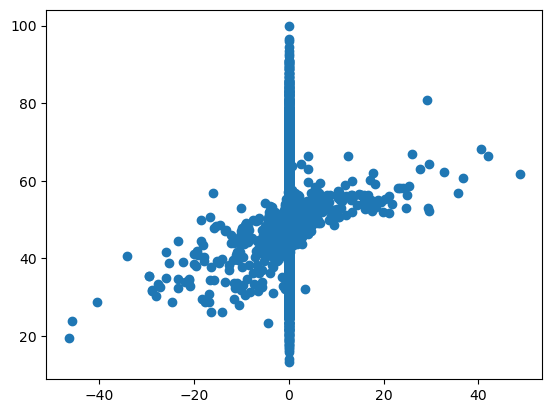

In [12]:
plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])
# plt.scatter(data['dem_funds_2p_pct'] - 50, data['dem_pct_2p'])

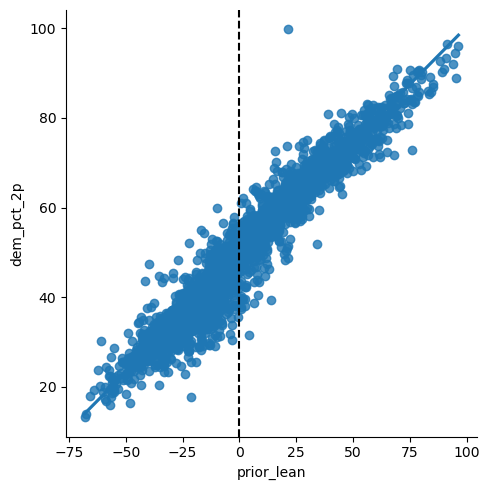

In [10]:
# plt.scatter(data['pvi'] - data['generic_ballot_avg'], data['dem_pct_2p'])
data['prior_lean'] = 2*data['pvi'] - data['generic_ballot_avg']
sns.lmplot(
    data,
    x='prior_lean', y='dem_pct_2p'
)
plt.axvline(0, color='black', linestyle='--')

In [11]:
# sns.scatterplot(
#     data.reset_index(),
#     x='rep_scandal_score', y='dem_pct_2p', hue='year' 
# )

In [12]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']
data['baseline'] = data['pvi']*2 - data['generic_ballot_avg']
data['funds_pct_margin'] = (data['dem_tot_funds'] - data['rep_tot_funds']) / (data['dem_tot_funds'] + data['rep_tot_funds'] + 0.001) * 100

## Preliminary Model Check (Frequentist OLS)

In [13]:
y = data['dem_pct_2p'] - 50
X = data[['baseline',
         #'inc_dummy', 'funds_pct_margin', 'dem_scandal_score', 'rep_scandal_score', 
          'effnXmargin']]
         # 'cvap_black_pct', 'cvap_hisp_pct', 'cvap_natam_pct', 'cvap_aapi_pct',
         #'effnXmargin',]] 
          #'college']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [14]:
X.corr()

,baseline,effnXmargin
baseline,1.000000,0.003642
effnXmargin,0.003642,1.000000


In [15]:
np.linalg.matrix_rank(X)

np.int64(2)

In [16]:
#X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             dem_pct_2p   R-squared (uncentered):                   0.928
Model:                            OLS   Adj. R-squared (uncentered):              0.928
Method:                 Least Squares   F-statistic:                          1.284e+04
Date:                Sat, 15 Aug 2026   Prob (F-statistic):                        0.00
Time:                        11:08:02   Log-Likelihood:                         -4561.6
No. Observations:                1561   AIC:                                      9127.
Df Residuals:                    1559   BIC:                                      9138.
Df Model:                           2                                                  
Covariance Type:                  HC1                                                  
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
baseline        0.5070      0.003    160.214      0.000       0.501       0.513
effnXmargin     0.0003   5.04e-05      5.818      0.000       0.000       0.000
==============================================================================
Omnibus:                      220.108   Durbin-Watson:                   1.952
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2160.853
Skew:                           0.295   Prob(JB):                         0.00
Kurtosis:                       8.734   Cond. No.                         38.0
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are heteroscedasticity robust (HC1)
"""

In [17]:
y_test_hat = reg.predict(X_test)
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(20.49941306985044), np.float64(3.424871328682243))

In [18]:
y_test - y_test_hat

year  district
2016  NE-02       2.876368
2020  OK-05       3.524398
2022  IL-06       1.548609
2016  PA-15      -9.235177
2020  PA-17       0.480372
                    ...   
2014  VA-04      -7.097851
2020  WV-02       2.105230
2014  NE-03      -0.522554
2024  NY-25       2.433282
      OH-11       1.507457
Length: 770, dtype: float64

In [19]:
X_test.corr()

,baseline,effnXmargin,residuals
baseline,1.000000,0.013043,-0.116456
effnXmargin,0.013043,1.000000,0.150778
residuals,-0.116456,0.150778,1.000000


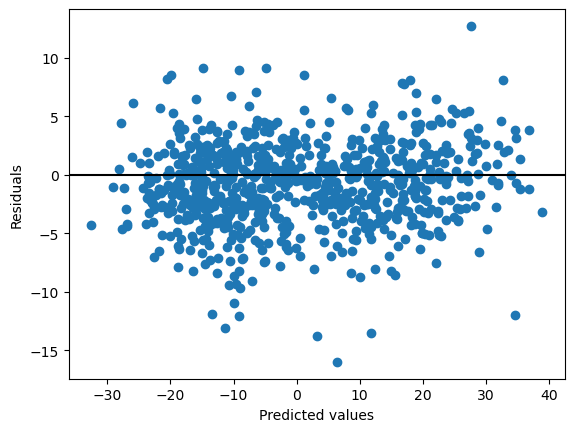

In [139]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [75]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

KeyError: 'prev2_lean'

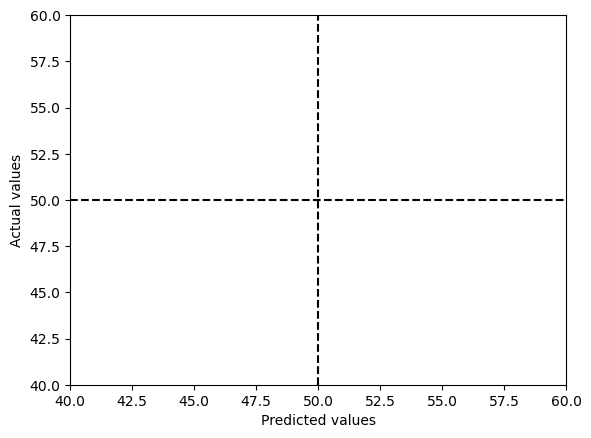

In [77]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

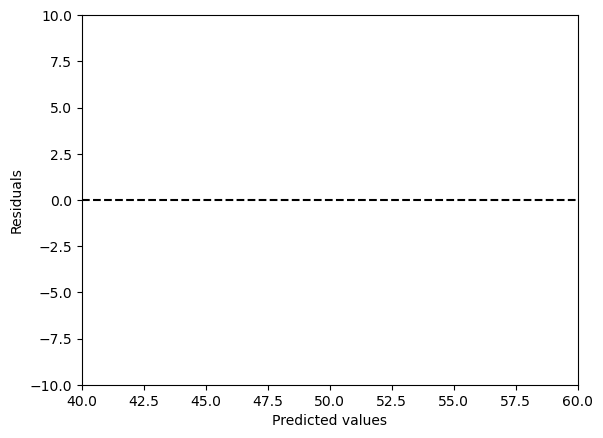

In [78]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


In [76]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

NameError: name 'resid' is not defined

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)